<a href="https://colab.research.google.com/github/officialaryansingh/machine_learning/blob/main/ML%20projects/Project_11_Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing the important dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Data Collection & Analysis

In [2]:
# loading the data from csv file to a Pandas DataFrame
insurance_dataset = pd.read_csv('/content/insurance.csv')

In [3]:
# first 5 rows of the data set
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_dataset.shape

(1338, 7)

In [5]:
# getting some informations about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Categorical Features:

. sex

. Smoker

. Region

Data Analysis

In [8]:
# stastical Measures of the dataset
insurance_dataset['age'].describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


<Figure size 600x600 with 0 Axes>

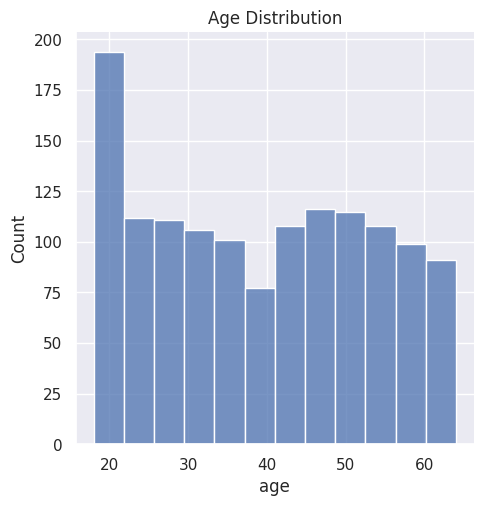

In [9]:
# distribution of the age value
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

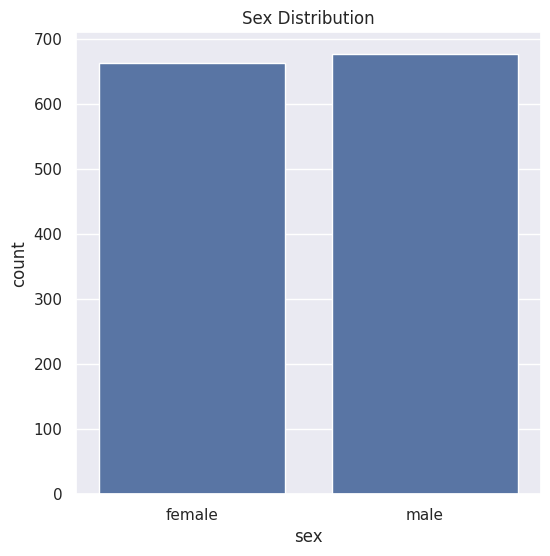

In [10]:
# General Column
plt.figure(figsize=(6,6))
sns.countplot(data = insurance_dataset,x='sex')
plt.title('Sex Distribution')
plt.show()

In [11]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


<Figure size 600x600 with 0 Axes>

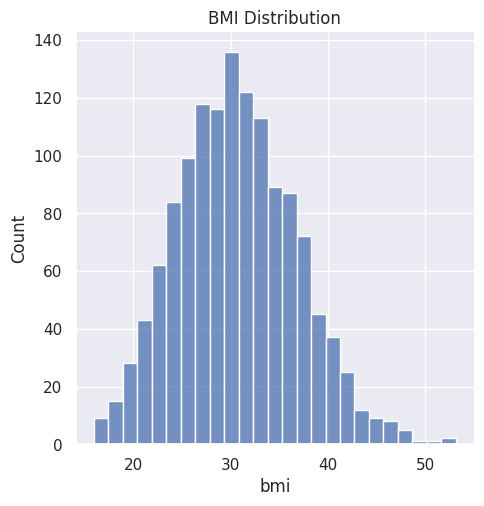

In [12]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['bmi'])
plt.title('BMI Distribution')
plt.show()

Normal BMI Range -->18.5 to 24.9

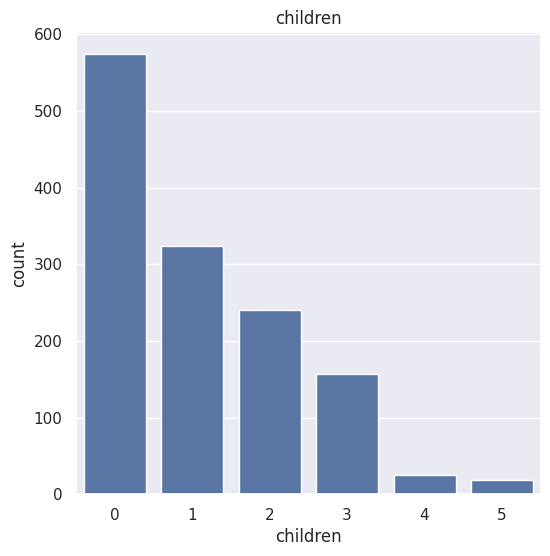

In [13]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(data = insurance_dataset,x='children')
plt.title('children')
plt.show()

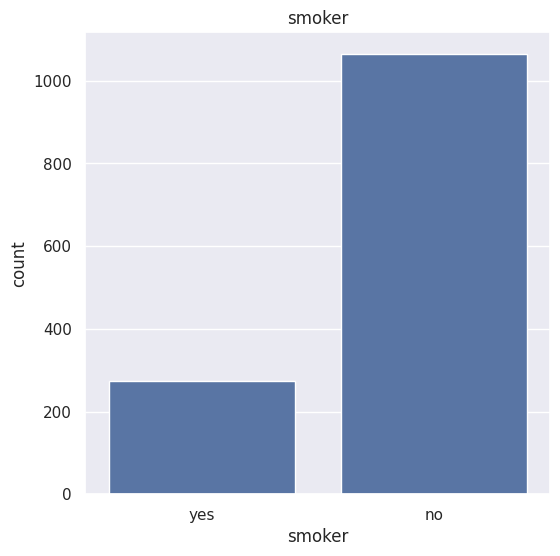

In [14]:
# smoker column
plt.figure(figsize=(6,6))
sns.countplot(x = 'smoker',data = insurance_dataset)
plt.title('smoker')
plt.show()

In [15]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


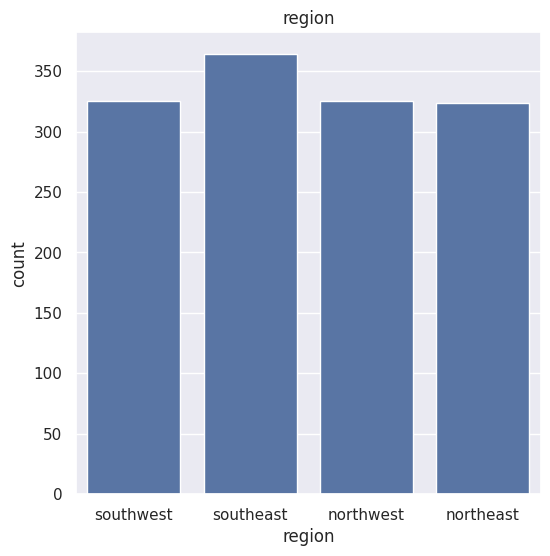

In [16]:
# region column
plt.figure(figsize =(6,6))
sns.countplot(x= 'region',data=insurance_dataset)
plt.title('region')
plt.show()

In [17]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


Data pre-Processing

Encoding the categorical features

In [18]:
# encoding the sex column
insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace = True)

# encoding 'smoker' column
insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace = True)

# encoding the region column
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace = True)

/tmp/ipykernel_22917/1579514704.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace = True)
/tmp/ipykernel_22917/1579514704.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace = True)
/tmp/ipykernel_22917/1579514704.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To o

Splitting the features and target

In [19]:
X = insurance_dataset.drop(columns = 'charges',axis = 1)
Y = insurance_dataset['charges']

In [20]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [21]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


Splitting the data into Training Data & Testing Data

In [22]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1,random_state = 2)

In [23]:
print(X.shape,X_test.shape,X_train.shape)

(1338, 6) (134, 6) (1204, 6)


Model Training

Linear Regression

In [24]:
# loading the Regressoin model
regressor = LinearRegression()

In [25]:
regressor.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [26]:
# Prediction on training data
training_data_prediction = regressor.predict(X_train)

In [27]:
# R squared value
r2_train = metrics.r2_score(Y_train,training_data_prediction)

In [28]:
print('R squared value : ',r2_train)

R squared value :  0.7533807289098102


In [29]:
# prediction on test data
test_data_prediction = regressor.predict(X_test)